In [42]:
import numpy as np
from numpy import random
import pandas as pd
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm


#from gdpc import __url__, Editor, Block

#editor = Editor(buffering=True)

sub_grid_init = np.loadtxt("sub_grid.csv",delimiter=",", dtype=object)

sub_grid = sub_grid_init.reshape((256, 256, 64))
sub_grid = np.flip(sub_grid,axis=2)
sub_grid[22,137,:]

array(['minecraft:grass_block[snowy=false]', 'minecraft:dirt',
       'minecraft:gold_ore', 'minecraft:gold_ore', 'minecraft:gold_ore',
       'minecraft:dirt', 'minecraft:gold_ore', 'minecraft:gold_ore',
       'minecraft:gold_ore', 'minecraft:gold_ore', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:stone', 'minecraft:stone', 'minecraft:stone',
       'minecraft:sto

In [44]:
#replacing minecraft block names with density values

density_grid = np.empty(shape = (256, 256, 64))
for x in range(0,256):
    for z in range(0,256):
        for y in range(0,64):
            if sub_grid[x,z,y] == "minecraft:grass_block[snowy=false]":
                density_grid[x,z,y] = 1.6
            if sub_grid[x,z,y] == "minecraft:dirt":
                density_grid[x,z,y] = 1.6
            if sub_grid[x,z,y] == "minecraft:stone":
                density_grid[x,z,y] = 2.4
            if sub_grid[x,z,y] == "minecraft:iron_ore":
                density_grid[x,z,y] = 10
            if sub_grid[x,z,y] == "minecraft:gold_ore":
                density_grid[x,z,y] = 20
            if sub_grid[x,z,y] == "minecraft:diamond_ore":
                density_grid[x,z,y] = 10


In [45]:
density_grid_b = np.ones(shape = (456, 456, 64))
for x in range(0,456):
    for y in range(0,456):
        for z in range(0,64):
            if z<7:
                density_grid_b[x,y,z]=1.6
            else:
                density_grid_b[x,y,z]=2.4

for x in range(0,256):
    for z in range(0,256):
        for y in range(0,64):
            if sub_grid[x,z,y] == "minecraft:grass_block[snowy=false]":
                density_grid_b[x+100,z+100,y] = 1.6
            if sub_grid[x,z,y] == "minecraft:dirt":
                density_grid_b[x+100,z+100,y] = 1.6
            if sub_grid[x,z,y] == "minecraft:stone":
                density_grid_b[x+100,z+100,y] = 2.4
            if sub_grid[x,z,y] == "minecraft:iron_ore":
                density_grid_b[x+100,z+100,y] = 10
            if sub_grid[x,z,y] == "minecraft:gold_ore":
                density_grid_b[x+100,z+100,y] = 20
            if sub_grid[x,z,y] == "minecraft:diamond_ore":
                density_grid_b[x+100,z+100,y] = 10

In [49]:
density_grid_b[122,237]

array([ 1.6,  1.6, 20. , 20. , 20. ,  1.6, 20. , 20. , 20. , 20. ,  2.4,
        2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,
        2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,
        2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,
        2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,
        2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4,  2.4])

In [63]:
density_grid_t = np.ones(shape = (50,50,20))
for x in range(0,50):
    for z in range(0,50):
        for y in range(0,20):
            if 30<x<41 and 10<z<16 and 10<y<16:
                density_grid_t[x,z,y]=10

In [100]:
G = 6.674e-11  # gravitational constant, m^3/kg/s^2

nx, ny, nz = 456, 456, 64 #number of cells
dx = dy = dz = 1  # cell size in meters

nx_obs, ny_obs, nz_obs = 65, 65, 32
dx_obs = dy_obs = 4

# Coordinates of cell centers
x = (np.arange(nx)) * dx
y = (np.arange(ny)) * dy
z = np.arange(-nz*dz, 0, dz)  # depth increasing downward

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Observation grid
x_o = (np.arange(nx_obs)) * dx_obs + 100
y_o = (np.arange(ny_obs)) * dy_obs + 100

x_obs, y_obs = np.meshgrid(x_o, y_o, indexing='ij')
z_obs = 0.0

y_obs
# Compute gravity at each observation point
gz = np.zeros_like(x_obs,dtype=float)
for i in tqdm(range(nx)):
    for j in range(ny):
        for k in range(nz):
           rx = x_obs - X[i,j,k]
           ry = y_obs - Y[i,j,k]
           rz = z_obs - Z[i,j,k]
           r3 = (rx**2 + ry**2 + rz**2)**1.5
           gz += G * density_grid_b[j,i,k] * dz * dy * dx * rz / r3

# Convert to mGal
gz_mgal = gz * 1e8

100%|██████████| 456/456 [33:38<00:00,  4.43s/it]


In [ ]:
G = 6.674e-11  # gravitational constant, m^3/kg/s^2

nx, ny, nz = 50, 50, 20 #number of cells
dx = dy = dz = 1  # cell size in meters

# Coordinates of cell centers
x = (np.arange(nx)-nx/2) * dx
y = (np.arange(ny)-ny/2) * dy
z = np.arange(-nz*dz, 0, dz)  # depth increasing downward

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Observation grid
x_obs, y_obs = np.meshgrid(x, y, indexing='ij')
z_obs = 0.0

# Compute gravity at each observation point
gz = np.zeros_like(x_obs,dtype=float)
for i in tqdm(range(nx)):
    for j in range(ny):
        for k in range(nz):
           rx = x_obs - X[i,j,k]
           ry = y_obs - Y[i,j,k]
           rz = z_obs - Z[i,j,k]
           r3 = (rx**2 + ry**2 + rz**2)**1.5
           gz+= G * density_grid_t[i,j,k] * dz * dy * dx * rz / r3

# Convert to mGal
gz_mgal = gz * 1e8

100%|██████████| 50/50 [00:03<00:00, 12.85it/s]


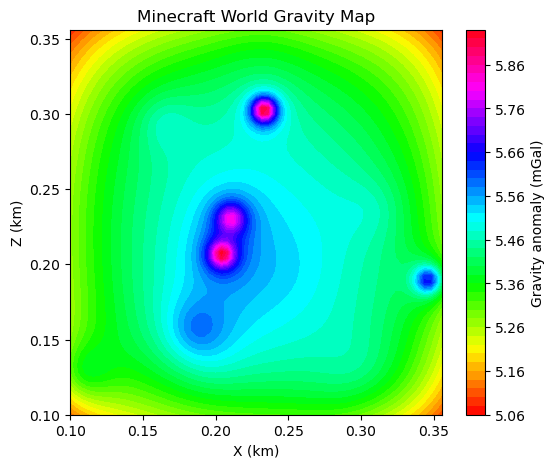

In [107]:
fig = plt.figure(figsize=(6,5))
plt.contourf(x_obs/1000, y_obs/1000, gz_mgal, 50, cmap='hsv')
plt.colorbar(label='Gravity anomaly (mGal)')
plt.xlabel('X (km)')
plt.ylabel('Z (km)')
plt.title('Minecraft World Gravity Map')
plt.show()
fig.savefig('gravity_first.png')

In [61]:
gz[:,0]

array([-2.28550580e-09, -2.46444197e-09, -2.61561265e-09, -2.74583048e-09,
       -2.85992421e-09, -2.96105866e-09, -3.05143287e-09, -3.13266043e-09,
       -3.20597724e-09, -3.27236224e-09, -3.33261176e-09, -3.38738770e-09,
       -3.43725009e-09, -3.48267986e-09, -3.52409505e-09, -3.56186266e-09,
       -3.59630710e-09, -3.62771604e-09, -3.65634394e-09, -3.68241339e-09,
       -3.70611425e-09, -3.72760036e-09, -3.74698379e-09, -3.76432648e-09,
       -3.77962968e-09, -3.79282190e-09, -3.80374675e-09, -3.81215315e-09,
       -3.81769048e-09, -3.81991177e-09, -3.81828692e-09, -3.81222637e-09,
       -3.80111300e-09, -3.78433815e-09, -3.76133632e-09, -3.73161341e-09,
       -3.69476472e-09, -3.65048010e-09, -3.59853506e-09, -3.53876682e-09,
       -3.47103493e-09, -3.39516644e-09, -3.31088576e-09, -3.21772832e-09,
       -3.11493275e-09, -3.00129546e-09, -2.87494890e-09, -2.73297777e-09,
       -2.57072554e-09, -2.38148473e-09])